# NASA Data Exploration

Loads and visualises the real-world shapefiles in `NASA/`:

| File | Content |
|------|---------|
| `test_basepoint.shp` | Single point: **GOOSE BAY** airbase (lon=-60.43°, lat=53.32°) — aircraft departure base |
| `test_polygon.shp` | Closed contour (LINESTRING, value=296) — likely a **PV contour** outlining a Tropopause Polar Vortex (TPV) |

The contour CRS is `ESRI:102010` (North America Equidistant Conic); the base point is `EPSG:4326` (WGS84).
Both are reprojected to WGS84 for visualisation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import geopandas as gpd
from shapely.geometry import Polygon as SPoly, Point
import math

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load shapefiles ───────────────────────────────────────────────────────
bp_raw   = gpd.read_file('NASA/test_basepoint.shp')
poly_raw = gpd.read_file('NASA/test_polygon.shp')

# Reproject both to WGS84
bp   = bp_raw.to_crs('EPSG:4326')
poly = poly_raw.to_crs('EPSG:4326')

base_pt  = bp.geometry.iloc[0]          # Point
contour  = poly.geometry.iloc[0]        # LineString (closed)
coords   = np.array(contour.coords)     # (N, 2) lon/lat
contour_poly = SPoly(coords)            # Shapely polygon for area queries

# ── Derived quantities ────────────────────────────────────────────────────
lon_c = coords[:-1, 0].mean()
lat_c = coords[:-1, 1].mean()
km_per_lon = 111.0 * math.cos(math.radians(lat_c))
km_per_lat = 111.0
area_km2   = contour_poly.area * km_per_lon * km_per_lat

# Equivalent radius of a circle with same area
equiv_radius_km = math.sqrt(area_km2 / math.pi)

# Great-circle distance BASE → contour centroid
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0
    dlon = math.radians(lon2 - lon1)
    dlat = math.radians(lat2 - lat1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

dist_base_to_center = haversine(base_pt.x, base_pt.y, lon_c, lat_c)

print(f'Base (GOOSE BAY):     lon={base_pt.x:.4f}°  lat={base_pt.y:.4f}°')
print(f'Contour centroid:     lon={lon_c:.4f}°  lat={lat_c:.4f}°')
print(f'Contour value:        {poly_raw["Contour"].iloc[0]:.0f}  (Id={poly_raw["Id"].iloc[0]})')
print(f'Contour perimeter:    {poly_raw["Shape_Leng"].iloc[0]/1e3:.1f} km')
print(f'Contour area:         ~{area_km2:.0f} km²')
print(f'Equiv. circle radius: ~{equiv_radius_km:.1f} km')
print(f'Base → centroid dist: ~{dist_base_to_center:.1f} km')
print(f'Num contour vertices: {len(coords) - 1}  (closed: first==last = {tuple(coords[0]) == tuple(coords[-1])})')

Base (GOOSE BAY):     lon=-60.4258°  lat=53.3192°
Contour centroid:     lon=-51.2525°  lat=47.0873°
Contour value:        296  (Id=1313)
Contour perimeter:    1322.3 km
Contour area:         ~86448 km²
Equiv. circle radius: ~165.9 km
Base → centroid dist: ~950.6 km
Num contour vertices: 110  (closed: first==last = True)


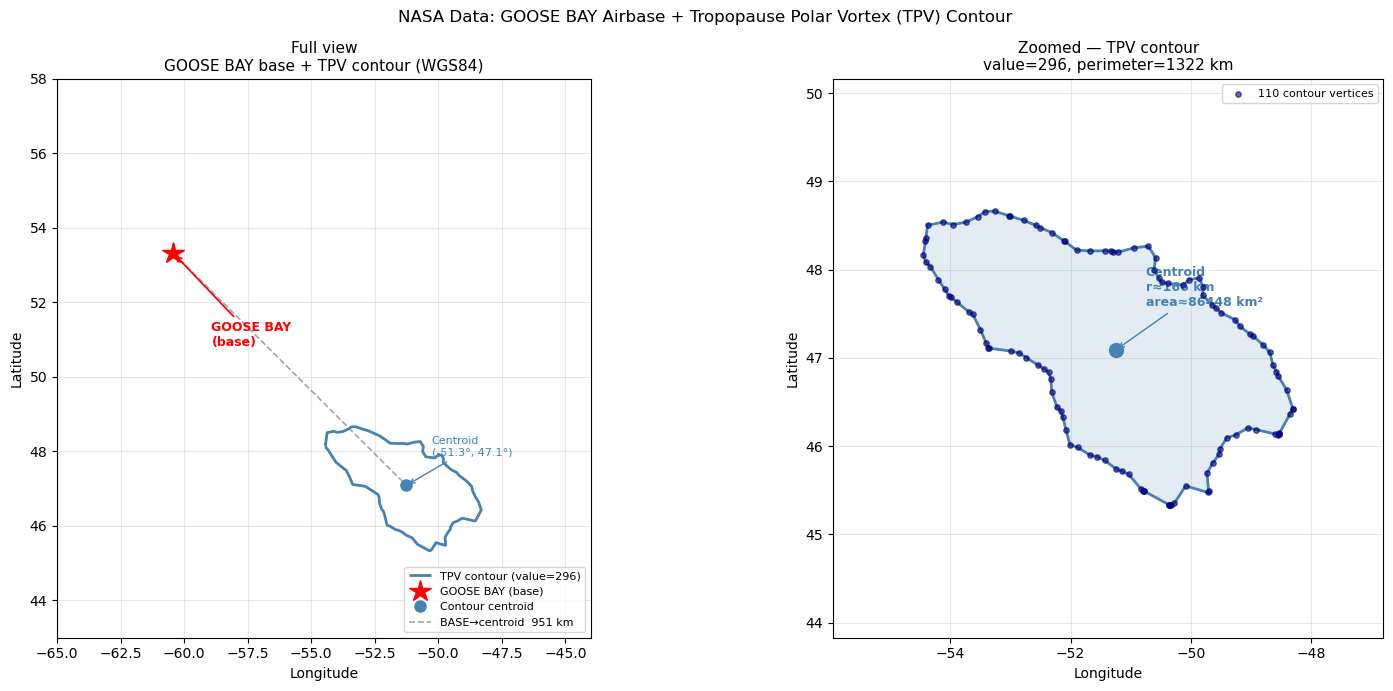

Saved → NASA/fig1_overview.png


In [3]:
# ── Figure 1: Overview map ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: full extent
ax = axes[0]
poly.plot(ax=ax, color='steelblue', linewidth=2, label=f'TPV contour (value={poly_raw["Contour"].iloc[0]:.0f})')
ax.plot(base_pt.x, base_pt.y, '*', color='red', markersize=16, zorder=5, label='GOOSE BAY (base)')
ax.annotate('GOOSE BAY\n(base)', xy=(base_pt.x, base_pt.y),
            xytext=(base_pt.x + 1.5, base_pt.y - 2.5),
            fontsize=9, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
ax.plot(lon_c, lat_c, 'o', color='steelblue', markersize=8, zorder=5, label='Contour centroid')
ax.annotate(f'Centroid\n({lon_c:.1f}°, {lat_c:.1f}°)',
            xy=(lon_c, lat_c), xytext=(lon_c + 1, lat_c + 0.8),
            fontsize=8, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))
# Draw line BASE → centroid
ax.plot([base_pt.x, lon_c], [base_pt.y, lat_c], '--', color='gray', lw=1.2, alpha=0.7,
        label=f'BASE→centroid  {dist_base_to_center:.0f} km')

ax.set_xlim(-65, -44); ax.set_ylim(43, 58)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Full view\nGOOSE BAY base + TPV contour (WGS84)', fontsize=11)
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

# Panel 2: zoomed on contour
ax = axes[1]
poly.plot(ax=ax, color='steelblue', linewidth=2)
# Fill the enclosed area
ax.fill(coords[:, 0], coords[:, 1], color='steelblue', alpha=0.15)
ax.plot(lon_c, lat_c, 'o', color='steelblue', markersize=10, zorder=5)
ax.annotate(f'Centroid\nr≈{equiv_radius_km:.0f} km\narea≈{area_km2:.0f} km²',
            xy=(lon_c, lat_c), xytext=(lon_c + 0.5, lat_c + 0.5),
            fontsize=9, color='steelblue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))
# Draw vertices
ax.scatter(coords[:-1, 0], coords[:-1, 1], s=15, color='navy', zorder=6, alpha=0.6,
           label=f'{len(coords)-1} contour vertices')
pad = 1.5
ax.set_xlim(coords[:, 0].min() - pad, coords[:, 0].max() + pad)
ax.set_ylim(coords[:, 1].min() - pad, coords[:, 1].max() + pad)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Zoomed — TPV contour\nvalue=296, perimeter={poly_raw["Shape_Leng"].iloc[0]/1e3:.0f} km', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('NASA Data: GOOSE BAY Airbase + Tropopause Polar Vortex (TPV) Contour', fontsize=12)
plt.tight_layout()
plt.savefig('NASA/fig1_overview.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()
print('Saved → NASA/fig1_overview.png')

Contour bounding box: 464 km (EW) × 370 km (NS)
Equiv. circle radius: 165.9 km
Base position in local frame: (-693, 692) km
Base → centroid distance: 979.4 km (local approx)


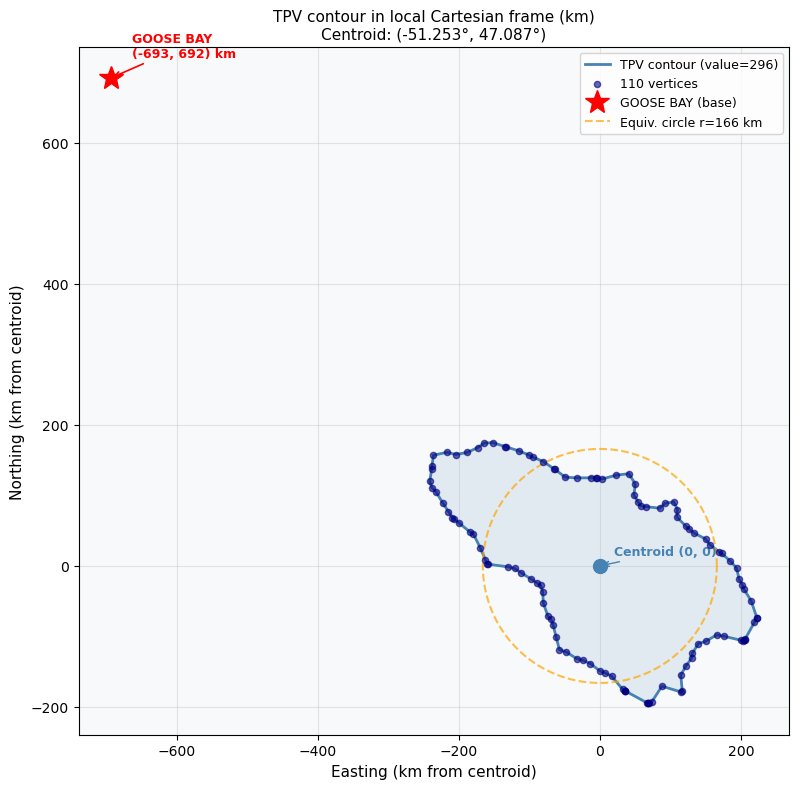

Saved → NASA/fig2_local_frame.png


In [4]:
# ── Figure 2: Local coordinate frame (km from centroid) ──────────────────
# Convert contour and base to a local Cartesian frame centred on the contour centroid.
# x = east (km), y = north (km)  — useful for route planning.

def lonlat_to_local_km(lon, lat, lon0, lat0):
    """Approximate local Cartesian (km) centred at (lon0, lat0)."""
    x = (lon - lon0) * 111.0 * math.cos(math.radians(lat0))
    y = (lat - lat0) * 111.0
    return x, y

# Contour in local km
cx = np.array([(lonlat_to_local_km(c[0], c[1], lon_c, lat_c))[0] for c in coords])
cy = np.array([(lonlat_to_local_km(c[0], c[1], lon_c, lat_c))[1] for c in coords])

# Base in local km
bx, by = lonlat_to_local_km(base_pt.x, base_pt.y, lon_c, lat_c)

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_facecolor('#f8f9fa')

ax.plot(cx, cy, color='steelblue', lw=2, label=f'TPV contour (value=296)')
ax.fill(cx, cy, color='steelblue', alpha=0.12)
ax.scatter(cx[:-1], cy[:-1], s=20, color='navy', zorder=5, alpha=0.6,
           label=f'{len(cx)-1} vertices')
ax.plot(0, 0, 'o', color='steelblue', markersize=10, zorder=6)
ax.annotate('Centroid (0, 0)', xy=(0, 0), xytext=(20, 15),
            fontsize=9, color='steelblue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))

ax.plot(bx, by, '*', color='red', markersize=18, zorder=7, label='GOOSE BAY (base)')
ax.annotate(f'GOOSE BAY\n({bx:.0f}, {by:.0f}) km',
            xy=(bx, by), xytext=(bx + 30, by + 30),
            fontsize=9, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

# Equivalent circle
theta_circ = np.linspace(0, 2*np.pi, 300)
ax.plot(equiv_radius_km * np.cos(theta_circ),
        equiv_radius_km * np.sin(theta_circ),
        '--', color='orange', lw=1.5, alpha=0.7,
        label=f'Equiv. circle r={equiv_radius_km:.0f} km')

# Bounding box
lon_range_km = (coords[:, 0].max() - coords[:, 0].min()) * km_per_lon
lat_range_km = (coords[:, 1].max() - coords[:, 1].min()) * km_per_lat
print(f'Contour bounding box: {lon_range_km:.0f} km (EW) × {lat_range_km:.0f} km (NS)')
print(f'Equiv. circle radius: {equiv_radius_km:.1f} km')
print(f'Base position in local frame: ({bx:.0f}, {by:.0f}) km')
print(f'Base → centroid distance: {math.sqrt(bx**2 + by**2):.1f} km (local approx)')

ax.set_aspect('equal')
ax.set_xlabel('Easting (km from centroid)', fontsize=11)
ax.set_ylabel('Northing (km from centroid)', fontsize=11)
ax.set_title('TPV contour in local Cartesian frame (km)\n'
             f'Centroid: ({lon_c:.3f}°, {lat_c:.3f}°)', fontsize=11)
ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('NASA/fig2_local_frame.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()
print('Saved → NASA/fig2_local_frame.png')

PCA ellipse fit:
  Major semi-axis a = 320.2 km
  Minor semi-axis b = 179.3 km
  Aspect ratio  a/b = 1.79
  Orientation   φ   = 145.3°  (from east, CCW)


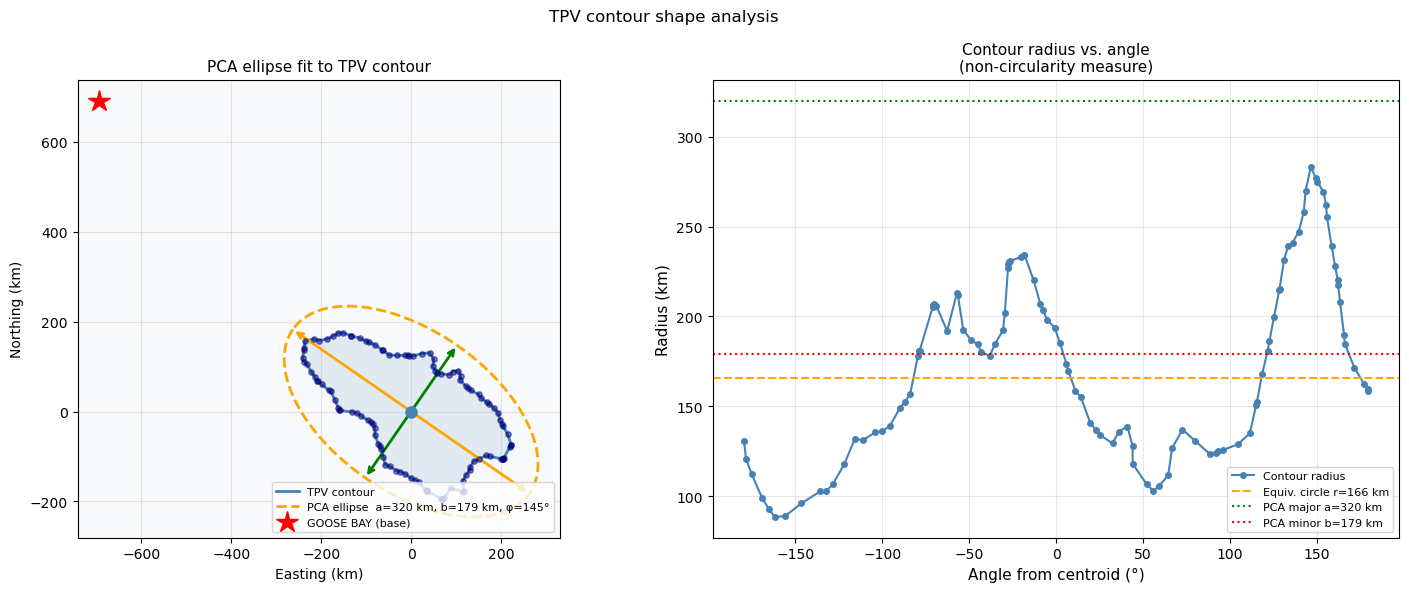

Saved → NASA/fig3_shape_analysis.png


In [5]:
# ── Figure 3: Contour shape analysis ─────────────────────────────────────
# Fit an ellipse to the contour vertices using PCA, to characterise its
# orientation and aspect ratio — useful for setting up survey parameters.

pts_local = np.column_stack([cx[:-1], cy[:-1]])   # (N, 2) in km

# PCA
mean = pts_local.mean(axis=0)
centered = pts_local - mean
cov = np.cov(centered.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Semi-axes: 2*std along each principal axis
a_pca = 2 * math.sqrt(eigenvalues[0])   # major semi-axis (km)
b_pca = 2 * math.sqrt(eigenvalues[1])   # minor semi-axis (km)
phi_pca = math.atan2(eigenvectors[1, 0], eigenvectors[0, 0])  # orientation (rad)

print(f'PCA ellipse fit:')
print(f'  Major semi-axis a = {a_pca:.1f} km')
print(f'  Minor semi-axis b = {b_pca:.1f} km')
print(f'  Aspect ratio  a/b = {a_pca/b_pca:.2f}')
print(f'  Orientation   φ   = {math.degrees(phi_pca):.1f}°  (from east, CCW)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: PCA ellipse overlay
ax = axes[0]
ax.set_facecolor('#f8f9fa')
ax.plot(cx, cy, color='steelblue', lw=2, label='TPV contour')
ax.fill(cx, cy, color='steelblue', alpha=0.12)
ax.scatter(pts_local[:, 0] + mean[0], pts_local[:, 1] + mean[1],
           s=15, color='navy', zorder=5, alpha=0.5)

# Draw PCA ellipse
t = np.linspace(0, 2*np.pi, 300)
ellipse_local = np.column_stack([a_pca * np.cos(t), b_pca * np.sin(t)])
R = np.array([[math.cos(phi_pca), -math.sin(phi_pca)],
              [math.sin(phi_pca),  math.cos(phi_pca)]])
ellipse_world = (R @ ellipse_local.T).T + mean
ax.plot(ellipse_world[:, 0], ellipse_world[:, 1], '--', color='orange', lw=2,
        label=f'PCA ellipse  a={a_pca:.0f} km, b={b_pca:.0f} km, φ={math.degrees(phi_pca):.0f}°')

# Draw principal axes
for i, (col, lbl) in enumerate(zip(['orange', 'green'], ['Major axis', 'Minor axis'])):
    v = eigenvectors[:, i] * [a_pca, b_pca][i]
    ax.annotate('', xy=mean + v, xytext=mean - v,
                arrowprops=dict(arrowstyle='<->', color=col, lw=2.0))

ax.plot(bx, by, '*', color='red', markersize=16, zorder=7, label='GOOSE BAY (base)')
ax.plot(0, 0, 'o', color='steelblue', markersize=8, zorder=6)
ax.set_aspect('equal')
ax.set_xlabel('Easting (km)'); ax.set_ylabel('Northing (km)')
ax.set_title('PCA ellipse fit to TPV contour', fontsize=11)
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

# Panel 2: radial distance from centroid vs. angle
ax = axes[1]
angles = np.degrees(np.arctan2(pts_local[:, 1] - mean[1],
                                pts_local[:, 0] - mean[0]))
radii  = np.sqrt((pts_local[:, 0] - mean[0])**2 + (pts_local[:, 1] - mean[1])**2)
sort_idx = np.argsort(angles)
ax.plot(angles[sort_idx], radii[sort_idx], 'o-', color='steelblue', lw=1.5,
        markersize=4, label='Contour radius')
ax.axhline(equiv_radius_km, color='orange', ls='--', lw=1.5,
           label=f'Equiv. circle r={equiv_radius_km:.0f} km')
ax.axhline(a_pca, color='green', ls=':', lw=1.5, label=f'PCA major a={a_pca:.0f} km')
ax.axhline(b_pca, color='red', ls=':', lw=1.5, label=f'PCA minor b={b_pca:.0f} km')
ax.set_xlabel('Angle from centroid (°)', fontsize=11)
ax.set_ylabel('Radius (km)', fontsize=11)
ax.set_title('Contour radius vs. angle\n(non-circularity measure)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('TPV contour shape analysis', fontsize=12)
plt.tight_layout()
plt.savefig('NASA/fig3_shape_analysis.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()
print('Saved → NASA/fig3_shape_analysis.png')

In [6]:
# ── Summary ───────────────────────────────────────────────────────────────
print('=' * 60)
print('NASA DATA SUMMARY')
print('=' * 60)
print(f'Base:               GOOSE BAY  ({base_pt.x:.4f}°, {base_pt.y:.4f}°)')
print(f'TPV centroid:       ({lon_c:.4f}°, {lat_c:.4f}°)')
print(f'Base→centroid:      {dist_base_to_center:.1f} km')
print(f'Contour value:      {poly_raw["Contour"].iloc[0]:.0f}')
print(f'Contour perimeter:  {poly_raw["Shape_Leng"].iloc[0]/1e3:.1f} km')
print(f'Enclosed area:      ~{area_km2:.0f} km²')
print(f'Equiv. radius:      ~{equiv_radius_km:.1f} km')
print(f'PCA semi-axes:      a={a_pca:.1f} km, b={b_pca:.1f} km  (ratio={a_pca/b_pca:.2f})')
print(f'PCA orientation:    φ={math.degrees(phi_pca):.1f}°')
print(f'Num vertices:       {len(coords)-1}')
print(f'Is closed contour:  {tuple(coords[0]) == tuple(coords[-1])}')

NASA DATA SUMMARY
Base:               GOOSE BAY  (-60.4258°, 53.3192°)
TPV centroid:       (-51.2525°, 47.0873°)
Base→centroid:      950.6 km
Contour value:      296
Contour perimeter:  1322.3 km
Enclosed area:      ~86448 km²
Equiv. radius:      ~165.9 km
PCA semi-axes:      a=320.2 km, b=179.3 km  (ratio=1.79)
PCA orientation:    φ=145.3°
Num vertices:       110
Is closed contour:  True
